# YOLO Model mAP50-95 Range Analysis

This notebook evaluates trained YOLO models across the entire IoU threshold range (`0.50` to `0.95` with steps of `0.05`). It extracts the Average Precision (AP) for each class and plots the degradation curves inline.

In [1]:
%matplotlib inline
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from ultralytics import YOLO

# Project configuration
DATA_YAML = "../dataset/dataset.yaml"
SPLIT = "test"  # Split to validate on (val or test)
IMGSZ = 640
BATCH_SIZE = 16
DEVICE = "0" if torch.cuda.is_available() else "cpu"

# Weights paths relative to the analyst directory
MODELS_TO_EVALUATE = {
    "YOLOv8m (Custom)": "../runs/detect/yolov8m_traffic-4/weights/best.pt",
    "YOLOv9m (Custom)": "../mlruns/2/8d19415e89ef43a59b22079bb8e32fb6/artifacts/weights/best.pt",
    "YOLOv8m (Pretrained)": "../yolov8m.pt",
    "YOLOv9m (Pretrained)": "../yolov9m.pt"
}

IOU_THRESHOLDS = [round(0.50 + 0.05 * i, 2) for i in range(10)]

### 1. Define Evaluation Function
This function runs the YOLO validation loop and extracts raw `all_ap` values (shape `[nc, 10]`) representing performance at each threshold.

In [2]:
def run_iou_analysis(model_name, weights_path, data_path, split, batch_size, imgsz, device):
    """Run validation on a model and extract AP values at all IoU thresholds."""
    if not os.path.exists(weights_path):
        print(f"Skipping {model_name}: weights file not found at '{weights_path}'")
        return []

    print(f"Evaluating {model_name} from: {weights_path} on '{split}' split...")
    start_time = time.time()
    try:
        model = YOLO(weights_path)
        val_results = model.val(
            data=data_path,
            split=split,
            batch=batch_size,
            imgsz=imgsz,
            device=device,
            plots=False,
        )
    except Exception as e:
        print(f"Error evaluating {model_name}: {e}")
        return []

    print(f"Finished evaluating {model_name} in {time.time() - start_time:.2f}s.")

    if val_results is None or not hasattr(val_results, "box"):
        print(f"Warning: No box metrics found in validation results for {model_name}.")
        return []

    class_names = val_results.names
    all_ap = val_results.box.all_ap

    if all_ap is None or len(all_ap) == 0:
        print(f"Warning: Empty Average Precision (all_ap) array for {model_name}.")
        return []

    results_data = []
    
    # Calculate overall mAP at each IoU threshold (mean across classes)
    overall_ap_per_iou = np.mean(all_ap, axis=0)

    # 1. Add 'all' (mean across classes) row
    overall_row = {
        "Model": model_name,
        "Class": "all",
    }
    for idx, thresh in enumerate(IOU_THRESHOLDS):
        overall_row[f"AP@{int(thresh * 100)}"] = float(overall_ap_per_iou[idx])
    overall_row["mAP50-95"] = float(np.mean(overall_ap_per_iou))
    results_data.append(overall_row)

    # 2. Add class-specific rows
    for class_id in range(all_ap.shape[0]):
        class_name = class_names.get(class_id, f"class_{class_id}")
        class_row = {
            "Model": model_name,
            "Class": class_name,
        }
        for idx, thresh in enumerate(IOU_THRESHOLDS):
            class_row[f"AP@{int(thresh * 100)}"] = float(all_ap[class_id, idx])
        class_row["mAP50-95"] = float(np.mean(all_ap[class_id, :]))
        results_data.append(class_row)

    return results_data

### 2. Define Plotting Function
This function outputs the comparison charts inline for visual review.

In [3]:
def plot_map50_95(df):
    """Plot model comparison and class breakdown curves inline."""
    if df.empty:
        return

    ap_cols = [col for col in df.columns if col.startswith("AP@")]
    iou_vals = [int(col.split("@")[1]) / 100.0 for col in ap_cols]

    # Plot 1: Compare overall mAP curves across models
    plt.figure(figsize=(10, 6))
    overall_df = df[df["Class"] == "all"]

    for _, row in overall_df.iterrows():
        y_vals = [row[col] for col in ap_cols]
        plt.plot(
            iou_vals,
            y_vals,
            marker="o",
            linewidth=2.5,
            label=f"{row['Model']} (mAP50-95: {row['mAP50-95']:.4f})",
        )

    plt.xlabel("IoU Threshold", fontsize=12)
    plt.ylabel("mAP", fontsize=12)
    plt.title("Overall mAP @ IoU Thresholds (0.50 - 0.95)", fontsize=14, fontweight="bold")
    plt.xticks(iou_vals)
    plt.ylim(0, 1.05)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend(loc="lower left", fontsize=10)
    plt.tight_layout()
    plt.show()

    # Plot 2: Class-specific analysis
    models = df["Model"].unique()
    num_models = len(models)

    fig, axes = plt.subplots(num_models, 1, figsize=(10, 5 * num_models), squeeze=False)

    for i, model in enumerate(models):
        ax = axes[i, 0]
        model_df = df[(df["Model"] == model) & (df["Class"] != "all")]

        for _, row in model_df.iterrows():
            y_vals = [row[col] for col in ap_cols]
            ax.plot(
                iou_vals,
                y_vals,
                marker="x",
                linestyle="--",
                linewidth=1.8,
                label=f"Class: {row['Class']} (mAP50-95: {row['mAP50-95']:.4f})",
            )

        # Plot overall mean curve for reference
        overall_model_df = df[(df["Model"] == model) & (df["Class"] == "all")]
        if not overall_model_df.empty:
            row = overall_model_df.iloc[0]
            y_vals = [row[col] for col in ap_cols]
            ax.plot(
                iou_vals,
                y_vals,
                marker="o",
                color="black",
                linewidth=3.0,
                label=f"Overall Mean (mAP50-95: {row['mAP50-95']:.4f})",
            )

        ax.set_xlabel("IoU Threshold", fontsize=11)
        ax.set_ylabel("AP / mAP", fontsize=11)
        ax.set_title(f"Class Performance Range: {model}", fontsize=12, fontweight="bold")
        ax.set_xticks(iou_vals)
        ax.set_ylim(0, 1.05)
        ax.grid(True, linestyle="--", alpha=0.6)
        ax.legend(loc="lower left", fontsize=9)

    plt.tight_layout()
    plt.show()

### 3. Run Evaluation Loop
Run validation for all selected models on the specified dataset and store results in a DataFrame.

In [4]:
all_results = []
for name, path in MODELS_TO_EVALUATE.items():
    metrics = run_iou_analysis(name, path, DATA_YAML, SPLIT, BATCH_SIZE, IMGSZ, DEVICE)
    all_results.extend(metrics)

if all_results:
    df_results = pd.DataFrame(all_results)
    
    # Save the dataframe locally to CSV
    csv_out_path = "../map50_95_analysis.csv"
    df_results.to_csv(csv_out_path, index=False)
    print(f"\nSuccessfully saved evaluation data to '{csv_out_path}'")
    
    # Display the results table
    display(df_results)
else:
    print("[ERROR] No evaluation results were retrieved.")

Evaluating YOLOv8m (Custom) from: ../runs/detect/yolov8m_traffic-4/weights/best.pt on 'test' split...


Ultralytics 8.4.86 🚀 Python-3.10.18 torch-2.9.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 5804MiB)


Model summary (fused): 93 layers, 25,842,076 parameters, 0 gradients, 78.7 GFLOPs


val: Fast image access ✅ (ping: 0.1±0.0 ms, read: 2032.8±763.3 MB/s, size: 306.3 KB)


val: Scanning /media/khanhduong/1TB/master/25MCS-ML_2025-2026_S2_Final-Project/dataset/test/labels.cache... 507 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 507/507 92.5Mit/s 0.0s

...

                   car        154        250    0.00925      0.128    0.00663      0.004


            motorcycle         71         79          0          0   5.03e-07   5.03e-07


Speed: 0.4ms preprocess, 9.3ms inference, 0.0ms loss, 0.8ms postprocess per image


Finished evaluating YOLOv8m (Pretrained) in 6.77s.
Skipping YOLOv9m (Pretrained): weights file not found at '../yolov9m.pt'

Successfully saved evaluation data to '../map50_95_analysis.csv'


,Model,Class,AP@50,AP@55,AP@60,AP@65,AP@70,AP@75,AP@80,AP@85,AP@90,AP@95,mAP50-95
0,YOLOv8m (Custom),all,9.210174e-01,9.180889e-01,9.076361e-01,8.949620e-01,8.770251e-01,8.159590e-01,7.431402e-01,6.079116e-01,3.614849e-01,3.759403e-02,7.084819e-01
1,YOLOv8m (Custom),motorbike,9.019193e-01,8.925237e-01,8.731381e-01,8.421314e-01,7.919089e-01,6.949841e-01,5.548403e-01,3.304395e-01,1.042355e-01,5.063081e-03,5.991184e-01
2,YOLOv8m (Custom),car,9.502243e-01,9.488692e-01,9.449016e-01,9.292476e-01,9.102191e-01,8.773770e-01,8.088547e-01,6.695960e-01,4.192397e-01,5.642642e-02,7.514956e-01
3,YOLOv8m (Custom),truck,9.288539e-01,9.278909e-01,9.094328e-01,9.076196e-01,9.051231e-01,8.728951e-01,8.360046e-01,7.455028e-01,4.135459e-01,4.097566e-02,7.487844e-01
4,YOLOv8m (Custom),bus,9.030719e-01,9.030719e-01,9.030719e-01,9.008495e-01,9.008495e-01,8.185797e-01,7.728611e-01,6.861080e-01,5.089184e-01,4.791094e-02,7.345293e-01
5,YOLOv9m (Custom),all,1.153263e-01,1.070072e-01,9.199793e-02,7.066019e-02,4.429335e-02,2.618302e-02,1.642362e-02,9.005300e-03,3.023667e-03,2.508333e-04,4.841714e-02
6,YOLOv9m (Custom),motorbike,4.071417e-01,3.753187e-01,3.173136e-01,2.340490e-01,1.322761e-01,6.392084e-02,2.673836e-02,7.750284e-03,9.102507e-04,1.402525e-05,1.565433e-01
7,YOLOv9m (Custom),car,3.309170e-03,3.031034e-03,2.695539e-03,2.388781e-03,1.945473e-03,1.254054e-03,7.970211e-04,4.189814e-04,8.603568e-05,1.770538e-06,1.592786e-03
8,YOLOv9m (Custom),truck,5.084822e-02,4.967268e-02,4.797636e-02,4.619680e-02,4.294558e-02,3.955094e-02,3.815285e-02,2.784569e-02,1.109214e-02,9.875373e-04,3.552688e-02
9,YOLOv9m (Custom),bus,6.247397e-06,6.247397e-06,6.247397e-06,6.247397e-06,6.247397e-06,6.247397e-06,6.247397e-06,6.247397e-06,6.247397e-06,0.000000e+00,5.622657e-06


### 4. Plot Results Inline

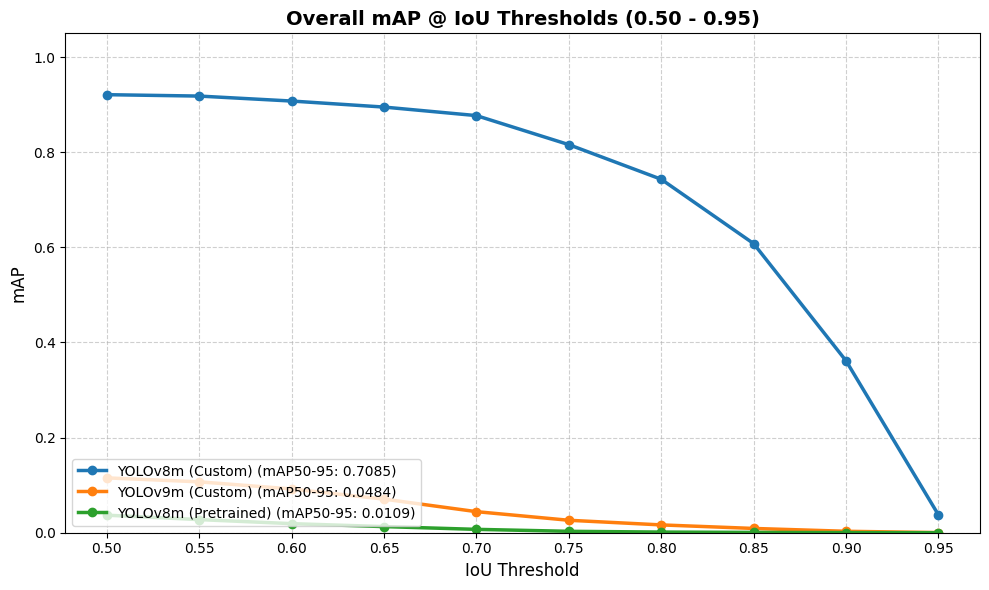

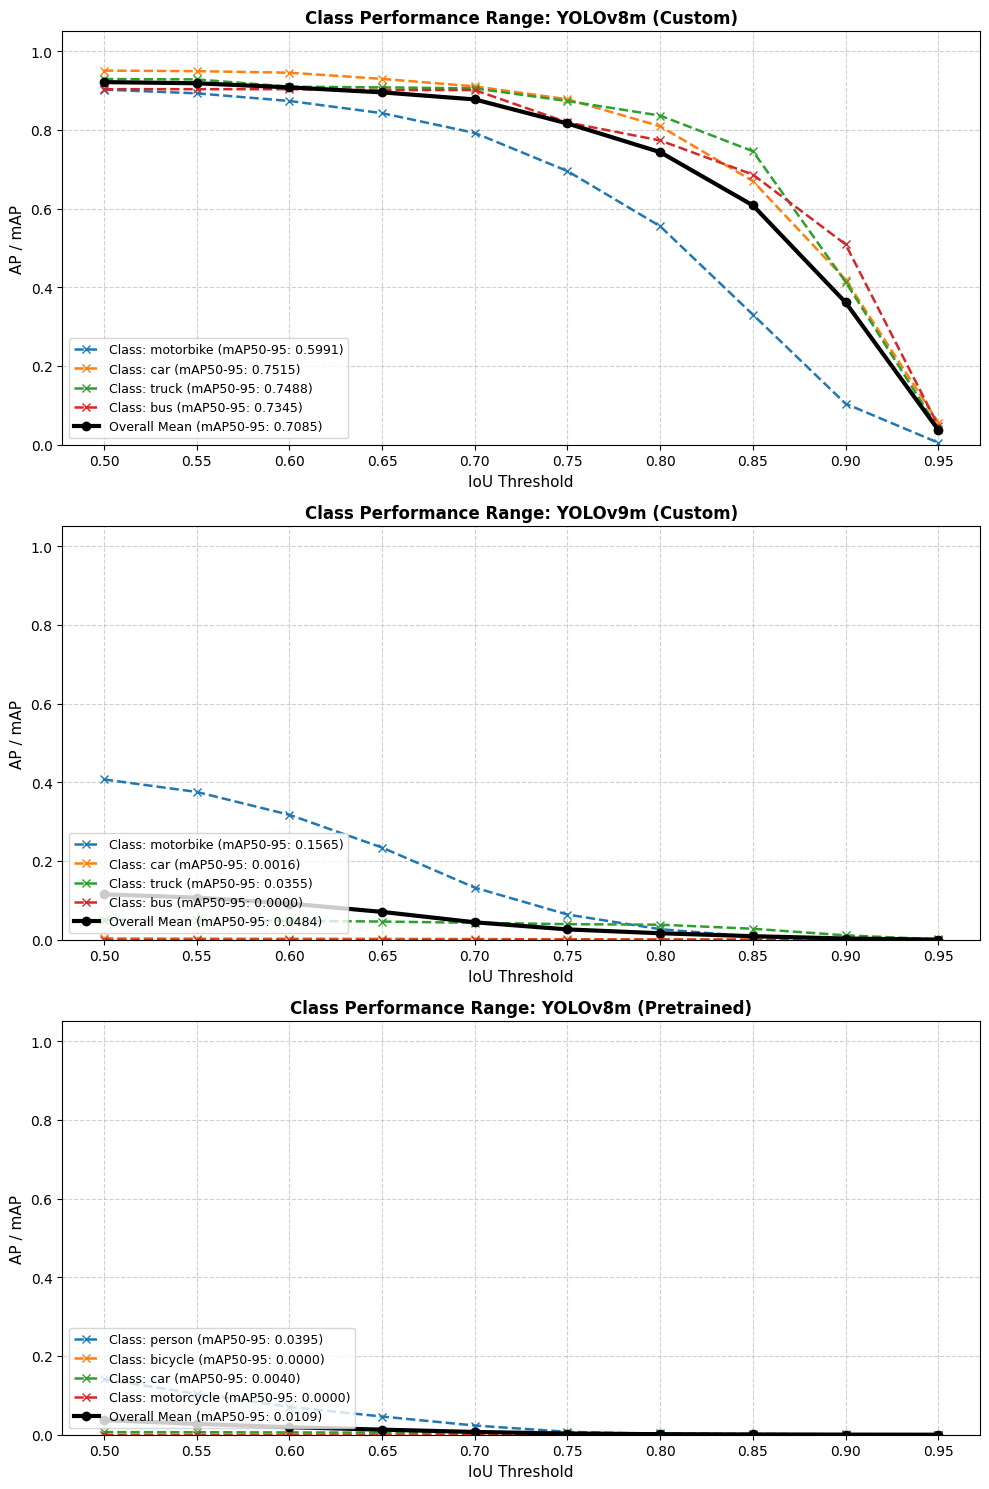

In [5]:
if "df_results" in locals() and not df_results.empty:
    plot_map50_95(df_results)